# Use case — anomaly detection on a stream of log events

Every log line is parsed into a numeric feature vector (latency, bytes, error rate, retries, …).
Healthy traffic forms a few dense **behavioral clusters**; incidents and attacks are rare points far
from all of them. Two ways `betula-cluster` flags them:

- **Batch** — fit on a healthy baseline, then `outlier_scores` / `find_outliers` rank new events.
- **Streaming** — `DbStream` over the live event stream labels anything that never joins a dense
  micro-cluster as **`-1` (noise)** — real-time, fading, bounded memory.

```bash
pip install betula-cluster matplotlib seaborn pandas scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score

from betula_cluster import Betula, DbStream

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
rng = np.random.default_rng(0)

FEATURES = ["latency_ms", "bytes", "req_per_min", "error_rate", "cpu", "cache_hit_ratio"]

## Healthy traffic + injected incidents

Three normal behaviors (e.g. cache hit, healthy GET, healthy POST) as dense clusters in 6-D; the
incidents are a **diffuse cloud** of rare events far from every healthy region (a latency / error
spike) — sparse and off-distribution, so they never form a dense cluster of their own.

In [2]:
centers = np.array([[0, 0, 0, 0, 0, 0], [7, 7, 0, 0, 0, 0], [0, 0, 7, 7, 0, 0]], dtype=float)
normal, _ = make_blobs(n_samples=8000, centers=centers, cluster_std=0.5, random_state=0)
n_anom = 160
anom = np.array([14.0, 14.0, 14.0, 0.0, 0.0, 0.0]) + 4.0 * rng.standard_normal((n_anom, 6))  # diffuse, far

train, normal_test = normal[:6000], normal[6000:]  # train on healthy only
test = np.vstack([normal_test, anom]).astype(np.float64)
is_anom = np.r_[np.zeros(len(normal_test), int), np.ones(n_anom, int)]
order = rng.permutation(len(test))
test, is_anom = test[order], is_anom[order]
print(f"train (healthy): {len(train)}   test: {len(test)} events ({is_anom.sum()} anomalies, {is_anom.mean():.1%})")

train (healthy): 6000   test: 2160 events (160 anomalies, 7.4%)


## Batch — score against a healthy baseline

`outlier_scores(X)` = distance to the assigned centroid ÷ that cluster's RMS radius. We never showed
the model an anomaly, yet they score far higher. ROC-AUC measures the ranking; precision@k checks the
top-`k` returned by `find_outliers` (what an on-call engineer would actually triage).

In [3]:
det = Betula(n_clusters=3, feature="diagonal", method="gmm", threshold=0.1, seed=1).fit(train)
scores = np.asarray(det.outlier_scores(test))
flagged = np.asarray(det.find_outliers(test, top_k=n_anom))

auc = roc_auc_score(is_anom, scores)
precision_at_k = float(is_anom[flagged].mean())
pd.DataFrame(
    {
        "metric": ["ROC-AUC (score vs ground truth)", f"precision@{n_anom} (find_outliers)", "median score normal", "median score anomaly"],
        "value": [round(auc, 3), f"{precision_at_k:.0%}", round(float(np.median(scores[is_anom == 0])), 2), round(float(np.median(scores[is_anom == 1])), 2)],
    }
)

,metric,value
0,ROC-AUC (score vs ground truth),1.0
1,precision@160 (find_outliers),100%
2,median score normal,0.96
3,median score anomaly,16.27


## The separation is clean

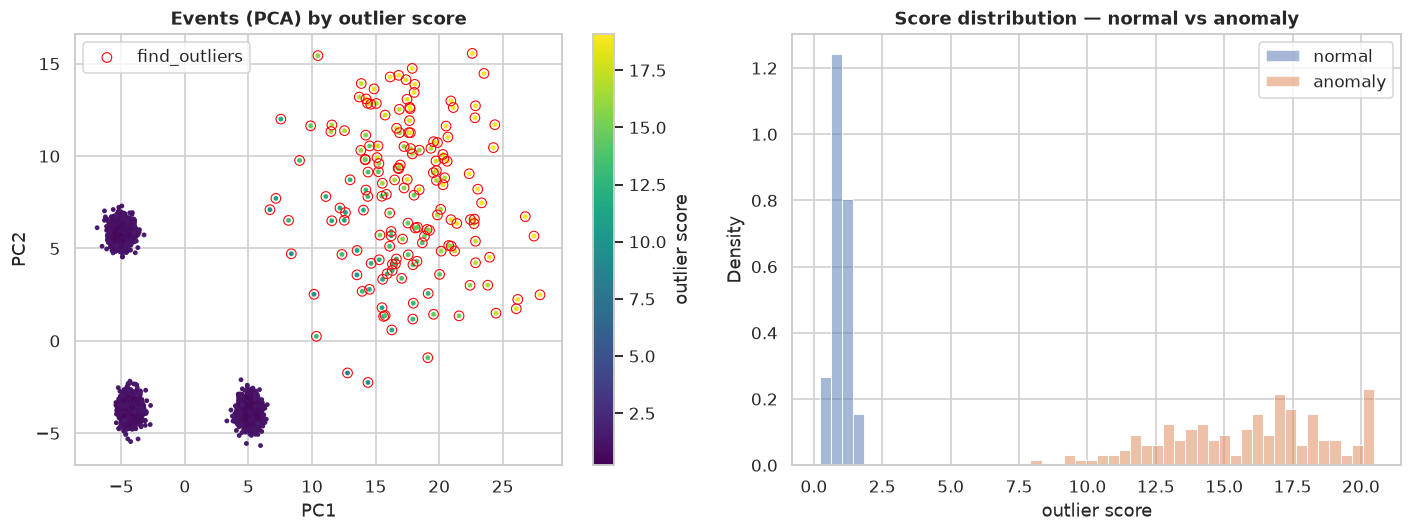

In [4]:
P = PCA(n_components=2, random_state=0).fit_transform(test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc = axes[0].scatter(P[:, 0], P[:, 1], c=np.clip(scores, 0, np.percentile(scores, 99)), cmap="viridis", s=10, linewidth=0)
axes[0].scatter(P[flagged, 0], P[flagged, 1], facecolors="none", edgecolors="red", s=40, linewidths=0.7, label="find_outliers")
axes[0].legend()
axes[0].set(title="Events (PCA) by outlier score", xlabel="PC1", ylabel="PC2")
plt.colorbar(sc, ax=axes[0], label="outlier score")

sns.histplot(x=np.clip(scores, 0, np.percentile(scores, 99.5)), hue=np.where(is_anom == 1, "anomaly", "normal"), bins=50, stat="density", common_norm=False, ax=axes[1])
axes[1].set(title="Score distribution — normal vs anomaly", xlabel="outlier score")
plt.tight_layout()
plt.show()

## Streaming — `DbStream` flags incidents in real time

Now treat events as a live stream: **continuous** healthy traffic, with an **incident burst** in the
last quarter. `DbStream` keeps fading micro-clusters; an event that never joins a dense one is
labelled `-1`. No baseline fit, no retraining — and memory is bounded no matter how long the stream
runs.

In [5]:
healthy = normal_test.copy()
rng.shuffle(healthy)
h_chunks = np.array_split(healthy, 40)  # continuous healthy traffic over 40 ticks
a_chunks = np.array_split(anom, 10)  # burst injected over the last 10 ticks
ticks = []
for i, hc in enumerate(h_chunks):
    ticks.append((hc, np.zeros(len(hc), int)))
    if i >= 30:
        ticks.append((a_chunks[i - 30], np.ones(len(a_chunks[i - 30]), int)))

db = DbStream(r=2.0, decay=0.01, alpha=0.1, min_weight=3.0)
for ev, _lab in ticks:
    db.partial_fit(ev)

stream = np.vstack([ev for ev, _ in ticks]).astype(np.float64)
stream_is_anom = np.concatenate([lab for _, lab in ticks])
flag = np.asarray(db.predict(stream)) < 0  # -1 == noise == flagged

recall = float(flag[stream_is_anom == 1].mean())
false_alarm = float(flag[stream_is_anom == 0].mean())
pd.DataFrame(
    {
        "metric": ["anomalies flagged (recall)", "healthy events flagged (false alarm)", "dense clusters tracked"],
        "value": [f"{recall:.0%}", f"{false_alarm:.1%}", db.n_clusters_],
    }
)

,metric,value
0,anomalies flagged (recall),100%
1,healthy events flagged (false alarm),1.6%
2,dense clusters tracked,3


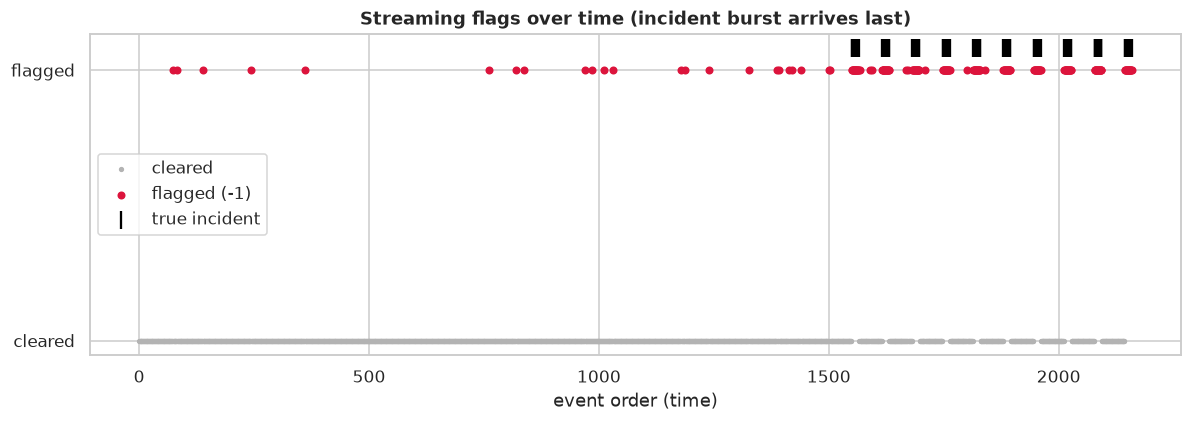

In [6]:
t = np.arange(len(stream))
fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(t[~flag], np.zeros((~flag).sum()), s=6, color="0.7", label="cleared")
ax.scatter(t[flag], np.ones(flag.sum()), s=18, color="crimson", label="flagged (-1)")
ax.scatter(t[stream_is_anom == 1], np.full((stream_is_anom == 1).sum(), 1.08), marker="|", s=140, color="black", label="true incident")
ax.set(title="Streaming flags over time (incident burst arrives last)", xlabel="event order (time)", yticks=[0, 1], yticklabels=["cleared", "flagged"])
ax.legend(loc="center left")
plt.tight_layout()
plt.show()

## When to use which

- **Batch `outlier_scores`** when you have a clean baseline and want a *ranked* triage list with a
  tunable threshold (ROC-AUC above).
- **Streaming `DbStream`** when behavior *evolves* and you need real-time flags with no retraining;
  `decay` controls how fast yesterday's normal stops counting. For evolving-stream mechanics see
  [`06_streaming_density`](../06_streaming_density.ipynb); for drift monitoring of the batch model see
  [`12_drift_robust_memory`](../12_drift_robust_memory.ipynb).